In [ ]:
#initialize
from pathlib import Path
import os

os.environ["WANDB_DISABLED"] = "true"

PROJECT_DIR = Path.cwd()

INPUT_H5AD = PROJECT_DIR / "input_data" / "01_primary_celltype" / "01_primary_celltype.h5ad"
TOKEN_DIR = PROJECT_DIR / "tokenized_data" / "01_primary_celltype"
RUN_DIR = PROJECT_DIR / "runs_geneformer_v2" / "01_primary_celltype"

BASE_MODEL_DIR = PROJECT_DIR.parent / "Geneformer-V2-104M"  # change if your model is elsewhere

TOKEN_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)

print("Input:", INPUT_H5AD)
print("Token dir:", TOKEN_DIR)
print("Run dir:", RUN_DIR)
print("Base model:", BASE_MODEL_DIR)

In [ ]:
#input check
import scanpy as sc

# Keep Scanpy plots compact for notebook viewing
sc.settings.set_figure_params(dpi=100, dpi_save=100)

adata_check = sc.read_h5ad(INPUT_H5AD, backed="r")

print(adata_check)
print(adata_check.obs.columns.tolist())
print(adata_check.obs["disease"].value_counts())
print(adata_check.obs["celltype"].value_counts())

adata_check.file.close()

In [ ]:
#tokenize
from geneformer import TranscriptomeTokenizer

tk = TranscriptomeTokenizer(
    custom_attr_name_dict={
        "cell_id": "cell_id",
        "individual": "individual",
        "celltype": "celltype",
        "disease": "disease",
    },
    chunk_size=512,
    model_input_size=2048,
    nproc=8,
    model_version="V2",
)

tk.tokenize_data(
    data_directory=str(INPUT_H5AD.parent),
    output_directory=str(TOKEN_DIR),
    output_prefix="01_primary_celltype",
    file_format="h5ad",
)

In [ ]:
#load it
from datasets import load_from_disk

TOKENIZED_DATASET = TOKEN_DIR / "01_primary_celltype.dataset"

ds = load_from_disk(str(TOKENIZED_DATASET))

print(ds)
print(ds.column_names)
print(ds[0].keys())

In [ ]:
import pandas as pd
import scanpy as sc
from sklearn.model_selection import train_test_split

ad = sc.read_h5ad(INPUT_H5AD, backed="r")
obs = ad.obs[["individual", "celltype"]].copy()
ad.file.close()

donor_df = (
    obs[["individual"]]
    .drop_duplicates()
    .sort_values("individual")
)

print("Total donors:", donor_df.shape[0])

In [ ]:
#cell 6 split
train_eval_ids, test_ids = train_test_split(
    donor_df["individual"].tolist(),
    test_size=0.20,
    random_state=42,
)

train_ids, eval_ids = train_test_split(
    train_eval_ids,
    test_size=0.20,
    random_state=42,
)

print("Train donors:", len(train_ids))
print("Eval donors:", len(eval_ids))
print("Test donors:", len(test_ids))

for name, ids in {
    "train": train_ids,
    "eval": eval_ids,
    "test": test_ids,
}.items():
    subset = obs[obs["individual"].isin(ids)]
    print(f"\n{name}")
    print(subset["celltype"].value_counts())

In [ ]:
#V2 classifier
from geneformer import Classifier

cc = Classifier(
    classifier="cell",
    cell_state_dict={
        "state_key": "celltype",
        "states": "all",
    },
    filter_data=None,
    training_args={
        "num_train_epochs": 1,
        "learning_rate": 1e-4,
        "per_device_train_batch_size": 8,
        "seed": 42,
    },
    max_ncells=None,
    freeze_layers=6,
    num_crossval_splits=1,
    forward_batch_size=16,
    nproc=4,
    model_version="V2",
)

print("Classifier initialized.")

In [ ]:
# Cell 8 — Prepare Geneformer train/test datasets

train_test_split_dict = {
    "attr_key": "individual",
    "train": train_ids + eval_ids,
    "test": test_ids,
}

cc.prepare_data(
    input_data_file=str(TOKENIZED_DATASET),
    output_directory=str(RUN_DIR),
    output_prefix="01_primary_celltype",
    split_id_dict=train_test_split_dict,
)

print("Training and test datasets prepared.")

In [ ]:
#next fine tunning
#cell_state_dict={
#   "state_key": "disease",
#   "states": "all",
#

In [ ]:
#metrics
train_eval_split_dict = {
    "attr_kezy": "individual",
    "train": train_ids,
    "eval": eval_ids,
}

metrics = cc.validate(
    model_directory=str(BASE_MODEL_DIR),
    prepared_input_data_file=str(RUN_DIR / "01_primary_celltype_labeled_train.dataset"),
    id_class_dict_file=str(RUN_DIR / "01_primary_celltype_id_class_dict.pkl"),
    output_directory=str(RUN_DIR),
    output_prefix="01_primary_celltype",
    split_id_dict=train_eval_split_dict,
    n_hyperopt_trials=0,
)

metrics

In [ ]:
saved_models = sorted(RUN_DIR.glob("*geneformer_cellClassifier*/ksplit1"))

print("Saved models:")
for m in saved_models:
    print(m)

MODEL_STAGE1 = saved_models[-1]
print("\nMODEL_STAGE1:")
print(MODEL_STAGE1)

In [ ]:
#test assessment
test_metrics = cc.evaluate_saved_model(
    model_directory=str(MODEL_STAGE1),
    id_class_dict_file=str(RUN_DIR / "01_primary_celltype_id_class_dict.pkl"),
    test_data_file=str(RUN_DIR / "01_primary_celltype_labeled_test.dataset"),
    output_directory=str(RUN_DIR),
    output_prefix="01_primary_celltype_test",
)

test_metrics

In [ ]:
#save checkpoint
with open(RUN_DIR / "MODEL_STAGE1_PATH.txt", "w") as f:
    f.write(str(MODEL_STAGE1))

print("Saved:")
print(RUN_DIR / "MODEL_STAGE1_PATH.txt")

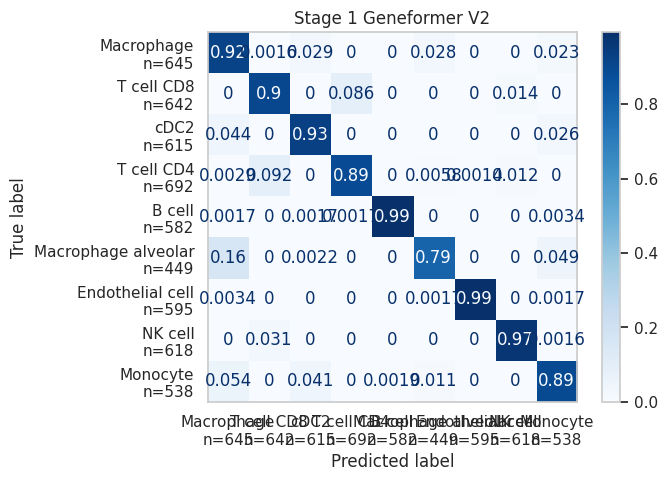

In [ ]:
#plot confusion
cc.plot_conf_mat(
    conf_mat_dict={"Stage 1 Geneformer V2": test_metrics["conf_matrix"]},
    output_directory=str(RUN_DIR),
    output_prefix="01_primary_celltype_test",
)

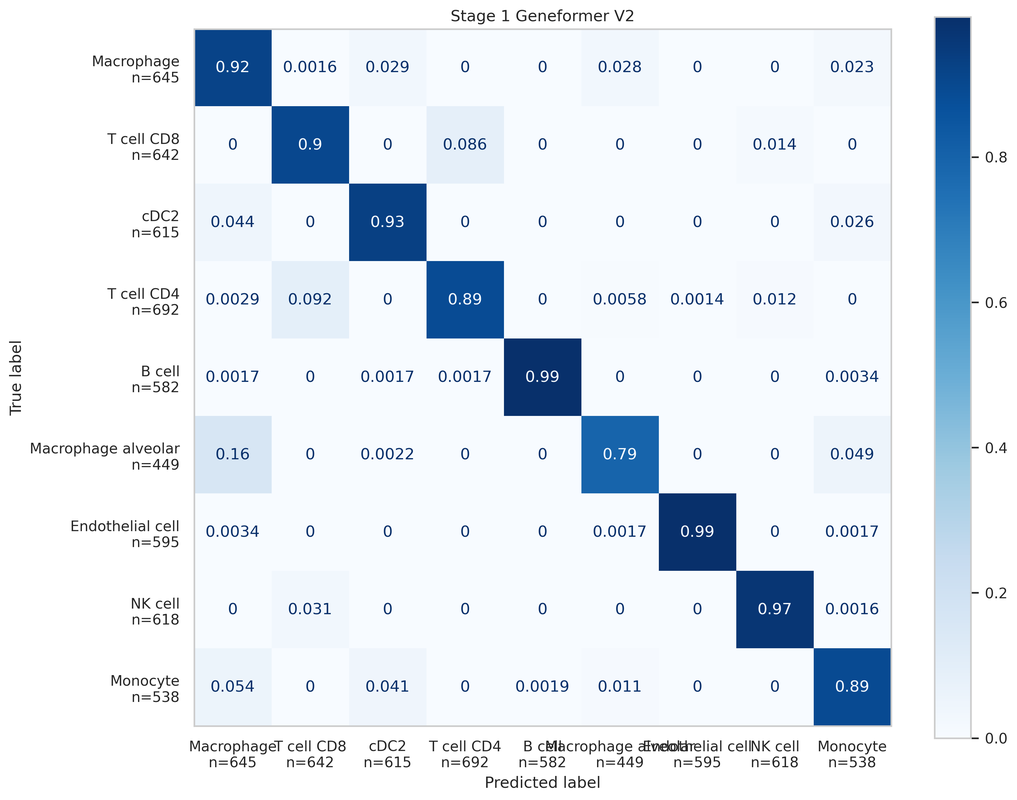

In [ ]:
import matplotlib.pyplot as plt

# Screen-friendly figures for notebooks and Git review
LOW_RES_DPI = 100
plt.rcParams.update({
    "figure.dpi": LOW_RES_DPI,
    "savefig.dpi": LOW_RES_DPI,
})

# 1. Temporarily increase global chart sizes and clear text spacing
plt.rcParams.update({
    'figure.figsize': (12, 10),      # Gives the plot plenty of breathing room
    'figure.dpi': 100,               # Uses screen-friendly low resolution
    'xtick.labelsize': 9,            # Makes axis text cleanly legible
    'ytick.labelsize': 9,
    'xtick.major.pad': 5,            # Pads text away from the matrix border
    'ytick.major.pad': 5
})

# 2. Run the original unchanged function block
cc.plot_conf_mat(
    conf_mat_dict={"Stage 1 Geneformer V2": test_metrics["conf_matrix"]},
    output_directory=str(RUN_DIR),
    output_prefix="01_primary_celltype_test",
)

# 3. Reset defaults so it doesn't distort your other script plots
plt.rcParams.update(plt.rcParamsDefault)

In [ ]:
#checkpoint
for f in sorted(RUN_DIR.glob("*")):
    print(f.name)

In [ ]:
import gc
import sys
import torch

# 1. List your heavy variables here to drop their tracking references
heavy_vars = ['adata_backed', 'filtered_obs', 'test_metrics', 'model', 'trainer', 'cc']

for var in heavy_vars:
    if var in globals():
        del globals()[var]
    if var in locals():
        del locals()[var]

# 2. Force Python to actively scan and collect unreferenced memory blocks
gc.collect()

# 3. Clear the PyTorch CUDA VRAM cache (Essential for GPU work)
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print("VRAM cache flushed successfully.")

print("Heavy workspace objects deleted and memory garbage collected.")